# All-models comparison â€” half-subs pipeline

Head-to-head ranking of every model variant trained on the half-with-subs dataset, against the **shared held-out test set** [`data/processed/test_snapshots_half_subs.parquet`](../../data/processed/). All loading + plotting helpers live in [`../comparison_half_subs.py`](../comparison_half_subs.py) â€” this notebook just calls them.

Two model families, eight variants each (kind Ã -  opponent Ã -  Â±stats), 16 runs total:

| Family | Folder prefix | What it sees |
|---|---|---|
| **tab-subs** | `tab_subs_<kind>_<opp>[_stats]` | Sub-aware XGBoost: 11 starters + 11 sub slots per team (position, archetype, start_min, duration, Â±stats). |
| **gnn-subs** | `gnn_subs_<kind>_<mode>_coords[_stats]` | [`HalfSubsGNN`](../gnn_subs.py): typed edges (intra-team / sub / time-overlap matchup), fully-connected intra-team with attention, sub-edge message passing. |

The starter-only `tab` family is excluded from this comparison. It can't see sub timing or identities at all, so head-to-head against the sub-aware models isn't apples-to-apples â€” and the `tab_subs` family is the proper flat-tabular control for what the GNN's typed sub-edges add. Numbers for the 8 `tab` runs still live under `artifacts/half_subs/tab_*/`.

*GNN `mode='single'` is treated as `opponent='ego'`; `mode='paired'` is treated as `opponent='matchup'` so the leaderboard rows align across families.*

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

# Make repo root importable when running from models/notebooks/.
ROOT = Path.cwd().resolve()
while not (ROOT / 'models' / 'comparison_half_subs.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('repo root not found')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd

from models.comparison_half_subs import (
    ablation_delta,
    ablation_summary,
    build_summary_table,
    load_runs,
    plot_metric_bars,
    plot_pred_vs_target,
    plot_residual_hists,
)

all_runs = load_runs(ROOT / 'artifacts' / 'half_subs')
# Drop the starter-only tab family; only consider sub-aware models.
runs = {k: r for k, r in all_runs.items() if r.family != 'tab'}
summary = build_summary_table(runs)
f'{len(runs)} runs loaded ({summary["family"].value_counts().to_dict()})'

"16 runs loaded ({'gnn_subs': 8, 'tab_subs': 8})"

## Leaderboard

Sorted ascending by MSE â€” best model on top. Lower MSE / MAE / RMSE is better; higher RÂ² / sign accuracy is better.

In [2]:
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
summary.drop(columns=['key']).round(4)

,family,kind,opponent,use_stats,MAE,RMSE,MSE,R²,sign acc
model,,,,,,,,,
gnn-subs · arch · matchup · stats,gnn_subs,archetype,matchup,True,0.3202,0.4326,0.1871,0.2826,0.6592
gnn-subs · arch · ego · stats,gnn_subs,archetype,ego,True,0.3217,0.4362,0.1902,0.2706,0.6519
tab-subs · pos · matchup · stats,tab_subs,position,matchup,True,0.3274,0.4407,0.1942,0.2555,0.6433
tab-subs · arch · matchup · stats,tab_subs,archetype,matchup,True,0.3246,0.4415,0.1949,0.2526,0.6467
gnn-subs · pos · matchup · stats,gnn_subs,position,matchup,True,0.3269,0.4431,0.1963,0.2473,0.6498
gnn-subs · pos · ego · stats,gnn_subs,position,ego,True,0.3276,0.4437,0.1969,0.2450,0.6352
gnn-subs · arch · ego,gnn_subs,archetype,ego,False,0.3415,0.4611,0.2126,0.1848,0.6174
gnn-subs · arch · matchup,gnn_subs,archetype,matchup,False,0.3419,0.4640,0.2153,0.1744,0.6067
tab-subs · arch · matchup,tab_subs,archetype,matchup,False,0.3446,0.4689,0.2198,0.1572,0.6151


## Family Ã -  kind Ã -  opponent â€” with model type as a side index

Conditioning on stats-on rows only. Family lives in the **row** index (not the column index) so reading down a column is reading a single metric across the design grid. Within each (kind, opponent) pair, compare `gnn_subs` against `tab_subs` to see whether the graph structure pays off for that personnel / opponent combination.

In [3]:
summary[summary['use_stats']].set_index(
    ['kind', 'opponent', 'family']
)[['MSE', 'R\u00b2', 'sign acc']].sort_index().round(4)

MSE      R²  sign acc
kind      opponent family                            
archetype ego      gnn_subs  0.1902  0.2706    0.6519
                   tab_subs  0.2298  0.1191    0.5973
          matchup  gnn_subs  0.1871  0.2826    0.6592
                   tab_subs  0.1949  0.2526    0.6467
position  ego      gnn_subs  0.1969  0.2450    0.6352
                   tab_subs  0.2240  0.1410    0.6028
          matchup  gnn_subs  0.1963  0.2473    0.6498
                   tab_subs  0.1942  0.2555    0.6433

## Marginal improvement â€” archetype vs position

Each row is `archetype âˆ’ position` on the same (family, opponent, use_stats) cell. Positive values = archetype helped (positive MSE delta means MSE dropped; positive RÂ² / sign-acc means they went up). Signs are normalized so **positive always means improvement**.

Key pattern: archetype identities lift the GNN universally but the tabular model only when stats are off. Once season stats are on, the flat tabular model already has the player-quality signal, so swapping position â†’ archetype labels adds nothing (and even slightly hurts via category cardinality).

In [4]:
ablation_delta(summary, 'kind').round(4)

MSE      R²  sign acc
family   opponent use_stats                          
gnn_subs ego      False      0.0408  0.1564    0.0715
                  True       0.0067  0.0256    0.0167
         matchup  False      0.0421  0.1613    0.0741
                  True       0.0092  0.0353    0.0094
tab_subs ego      False      0.0300  0.1150    0.0441
                  True      -0.0057 -0.0219   -0.0055
         matchup  False      0.0554  0.2123    0.0326
                  True      -0.0008 -0.0029    0.0034

## Marginal improvement â€” stats vs no-stats

Each row is `with-stats âˆ’ no-stats` on the same (family, kind, opponent) cell. Positive = stats helped.

This is universally positive and by far the largest effect â€” every cell gains RÂ² between +0.07 and +0.31. The biggest lift is on **position** runs where the no-stats baseline is weakest; archetype runs gain less from stats because the archetype categorical already carries most of the player-quality signal.

In [5]:
ablation_delta(summary, 'use_stats').round(4)

MSE      R²  sign acc
family   kind      opponent                          
gnn_subs archetype ego       0.0224  0.0858    0.0344
                   matchup   0.0282  0.1082    0.0525
         position  ego       0.0565  0.2166    0.0892
                   matchup   0.0611  0.2342    0.1172
tab_subs archetype ego       0.0185  0.0708    0.0136
                   matchup   0.0249  0.0954    0.0316
         position  ego       0.0542  0.2078    0.0632
                   matchup   0.0810  0.3107    0.0608

## Marginal improvement â€” gnn vs tab

Each row is `gnn_subs âˆ’ tab_subs` on the same (kind, opponent, use_stats) cell. Positive = the graph structure beat the flat tabular control. This is the **structural lift from the GNN topology** â€” both families see identical sub timing / identities, so what's left is whatever extra signal the typed edges (intra-team / sub / time-overlap matchup) plus attention pooling extract.

Positive in 7 of 8 cells (the lone exception is `position Â· matchup Â· stats` where the two tie within ~0.01 RÂ²). The biggest GNN wins are on **archetype** runs â€” `arch Â· ego Â· stats` (+0.15 RÂ²) and `arch Â· matchup Â· stats` (+0.03 RÂ²). The structural lift is biggest exactly when the GNN can combine archetype embeddings with topology.

In [6]:
ablation_delta(summary, 'family').round(4)

MSE      R²  sign acc
kind      opponent use_stats                          
archetype ego      False      0.0356  0.1365    0.0337
                   True       0.0395  0.1515    0.0545
          matchup  False      0.0045  0.0173   -0.0084
                   True       0.0078  0.0300    0.0125
position  ego      False      0.0248  0.0952    0.0063
                   True       0.0271  0.1040    0.0324
          matchup  False      0.0178  0.0683   -0.0498
                   True      -0.0021 -0.0082    0.0065

## Average marginal improvement per design choice

One row per axis, columns are the metrics. Each cell is the **mean delta over the other-axis grid** - i.e., averaged across every (other-axis) configuration where the comparison is well-defined. Positive = the named choice helped on average; negative = it hurt.

Reads as a one-line takeaway per design choice: how much R² (or sign accuracy) does the average user gain by flipping this one switch, holding every other design choice fixed?

In [7]:
ablation_summary(summary).round(4)

,MSE,R²,sign acc
archetype - position,0.0222,0.0851,0.0308
stats - no_stats,0.0433,0.1662,0.0578
gnn - tab,0.0194,0.0744,0.0110


## Metric bar chart

One subplot per metric, one bar per model, colored by family (orange = tab-subs, green = gnn-subs). Top end of every metric is occupied by the with-stats variants; the with-stats vs without gap dwarfs any cross-family gap.

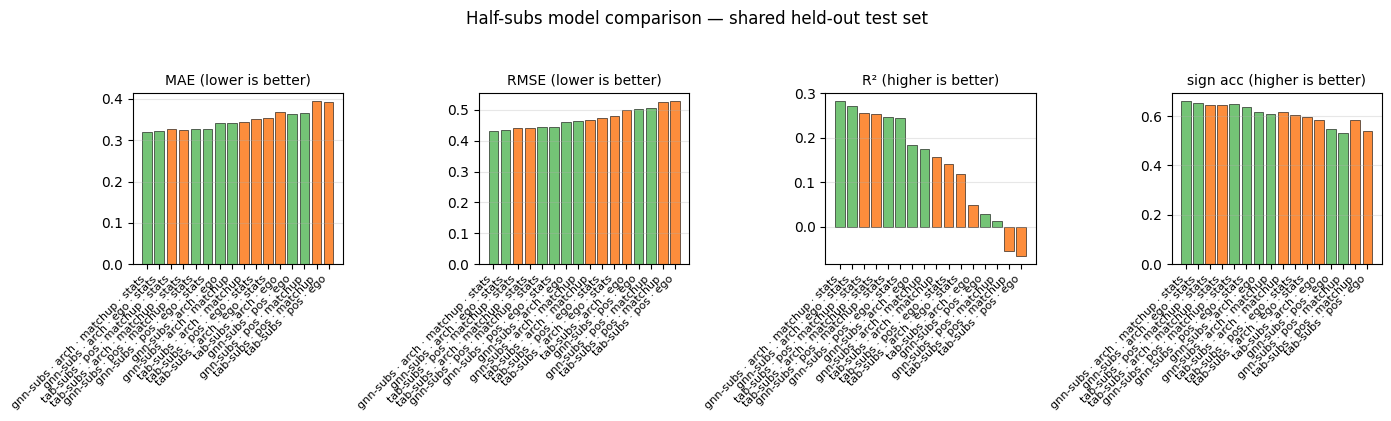

In [8]:
fig = plot_metric_bars(summary)

## Predictions vs targets

Scatter per model sorted by RMSE â€” diagonal is perfect prediction. Top-left models (with-stats, archetype) show meaningful spread along the diagonal; bottom-right models (no-stats, position) collapse toward the y-mean (a horizontal band).

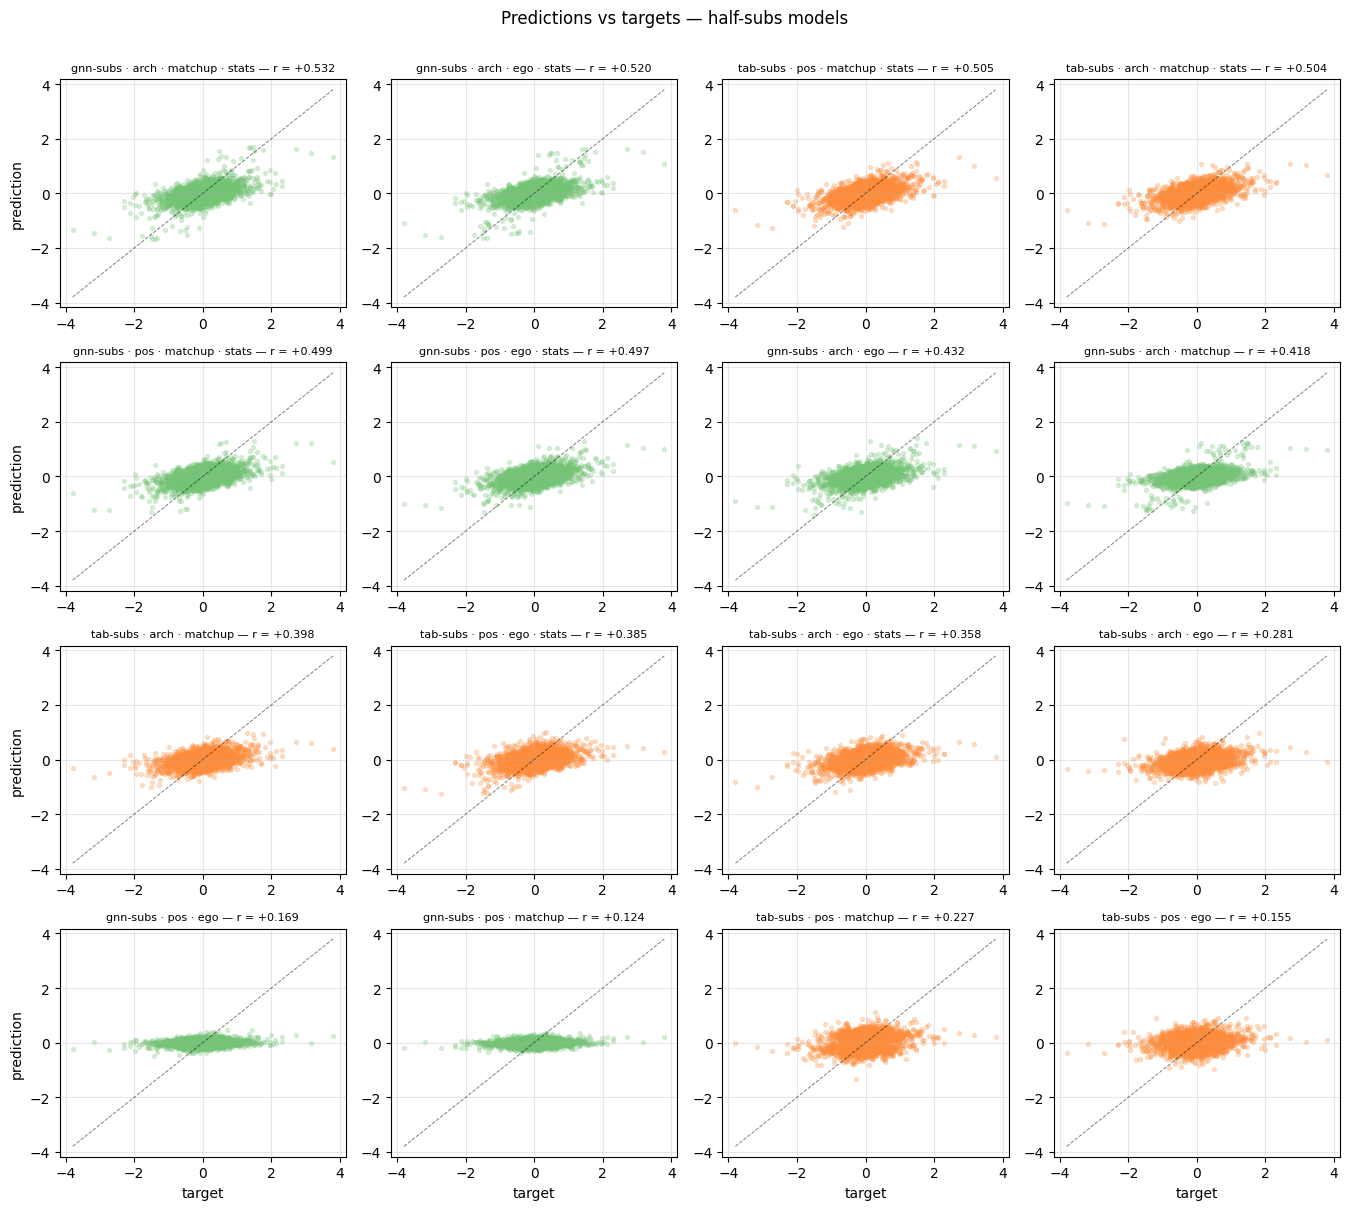

In [9]:
fig = plot_pred_vs_target(runs)

## Residual histograms

`pred âˆ’ target` distribution per model. Î¼ near 0 means unbiased; Ïƒ ranks the same way the leaderboard does. The best models show tighter, more symmetric residuals; the worst show heavy fat tails (rare blowout matches the model can't recover).

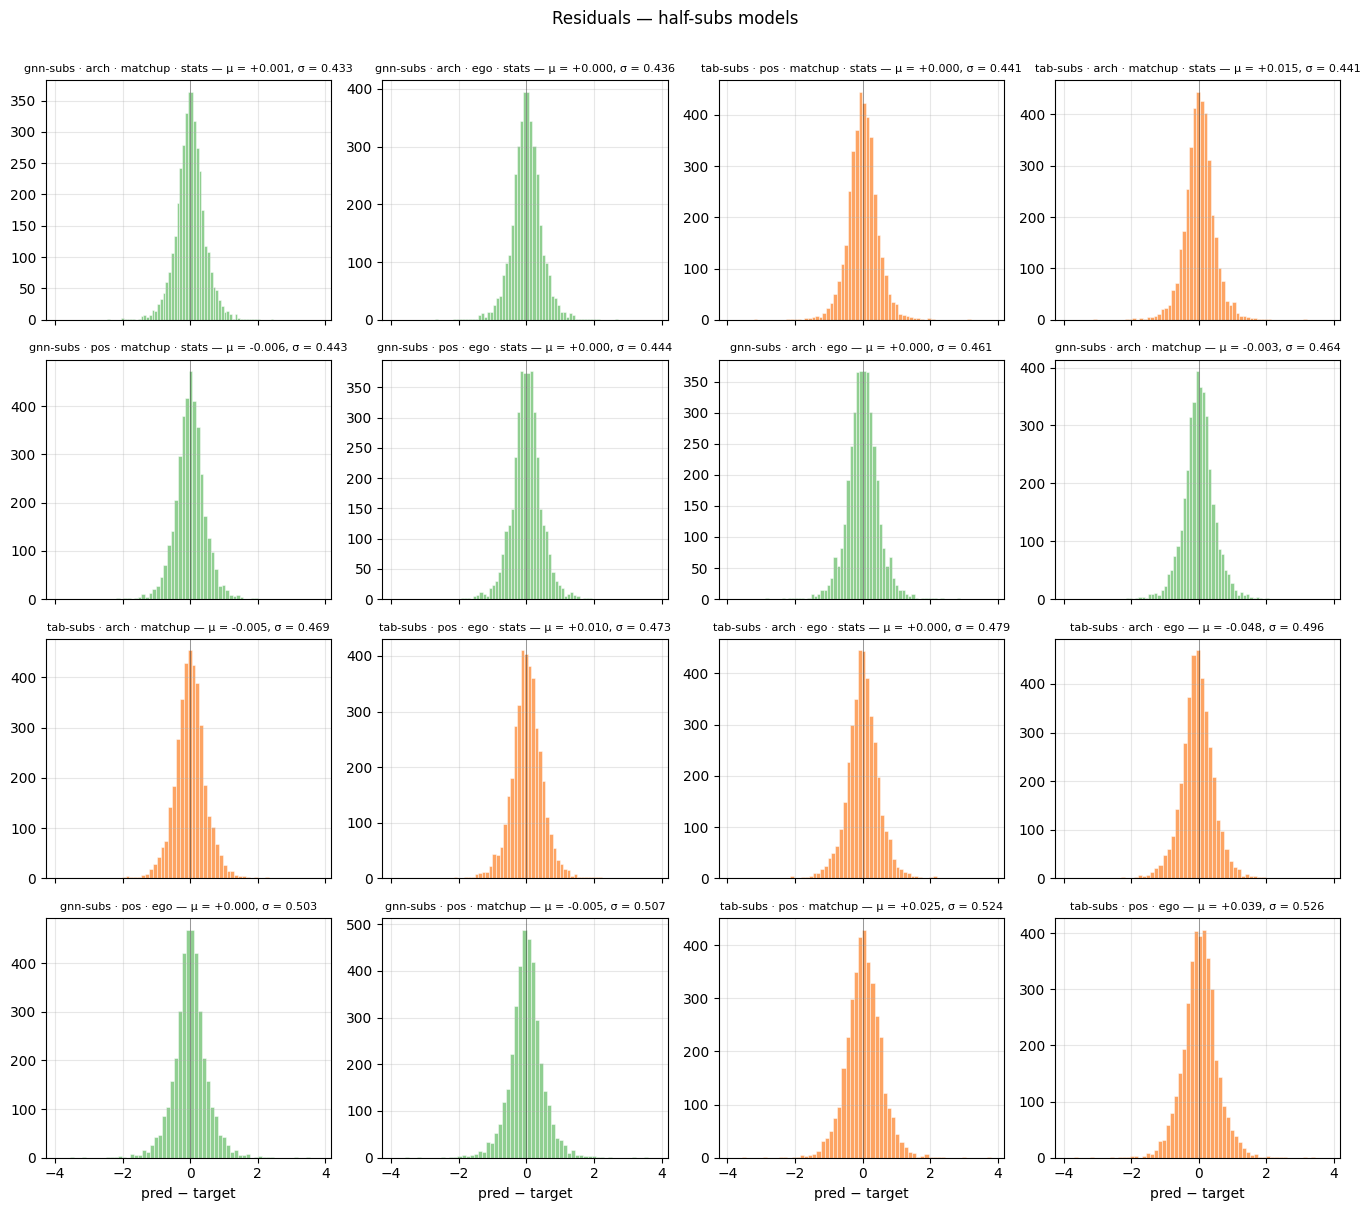

In [10]:
fig = plot_residual_hists(runs)